# Importation des bibliothèques

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation du jeu de données

In [3]:
def read_data():
    data_score_credit = pd.read_csv('../data/cs-training.csv')
    return data_score_credit

In [5]:
data_score_credit = read_data()
data_score_credit.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Renommage des colonnes pour qu'elles soient plus compréhensible.

In [7]:
data_score_credit.rename(columns={'SeriousDlqin2yrs': 'target',
                         'RevolvingUtilizationOfUnsecuredLines': 'taux_utilisation_credit',
                         'age': 'age',
                         'NumberOfTime30-59DaysPastDueNotWorse': 'nbr_30-59_jours_retard',
                         'DebtRatio': 'ratio_endettement',
                         'MonthlyIncome':'Revenus_mensuel', 
                         'NumberOfOpenCreditLinesAndLoans':'nbr_lignes_credit_ouvertes',
                         'NumberOfTimes90DaysLate': 'nbr_90_jours_retard',
                         'NumberRealEstateLoansOrLines': 'nbr_prets_immobilier',
                         'NumberOfTime60-89DaysPastDueNotWorse':'nbr_60-89_jours_retard',
                        'NumberOfDependents' : 'nbr_person_foyer'
                        

                         }, inplace=True)

data_score_credit.head()

,Unnamed: 0,target,taux_utilisation_credit,age,nbr_30-59_jours_retard,ratio_endettement,Revenus_mensuel,nbr_lignes_credit_ouvertes,nbr_90_jours_retard,nbr_prets_immobilier,nbr_60-89_jours_retard,nbr_person_foyer
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Visualisation des méta données

In [16]:
data_score_credit.isnull().sum()

Unnamed: 0                        0
target                            0
taux_utilisation_credit           0
age                               0
nbr_30-59_jours_retard            0
ratio_endettement                 0
Revenus_mensuel               29731
nbr_lignes_credit_ouvertes        0
nbr_90_jours_retard               0
nbr_prets_immobilier              0
nbr_60-89_jours_retard            0
nbr_person_foyer               3924
dtype: int64

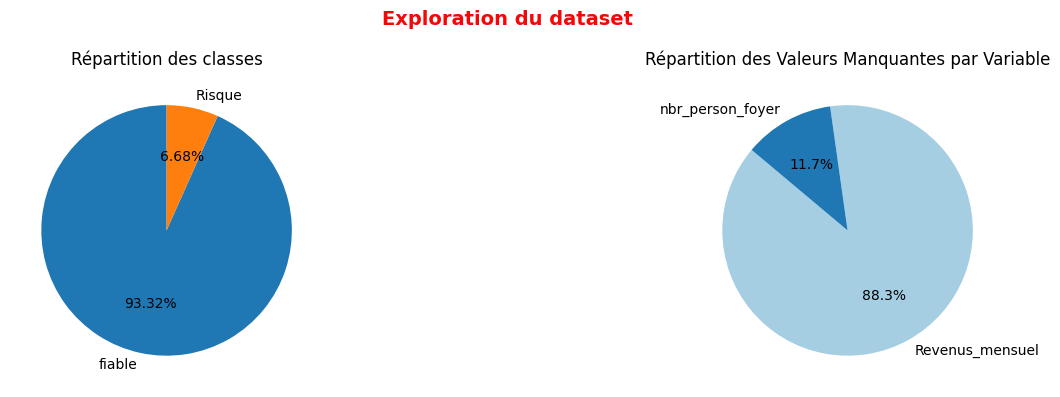

In [ ]:
target = data_score_credit['target'].value_counts()
valeur_manquante = data_score_credit.isnull().sum()
seul_valeur_manquante = valeur_manquante[valeur_manquante > 0]
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Exploration du dataset", color="#f40707", fontsize=14, fontweight='bold')

# Pie fraude
labels_pie = ['fiable', 'Risque']

axes[0].pie([target[0], target[1]], labels=labels_pie,
            autopct='%1.2f%%', startangle=90)
axes[0].set_title("Répartition des classes")


axes[1].pie(
        seul_valeur_manquante, 
        labels=seul_valeur_manquante.index, 
        autopct='%1.1f%%', # Affiche le pourcentage sur le cercle
        startangle=140, 
        colors=plt.cm.Paired.colors # Utilise une palette de couleurs variées
    )
axes[1].set_title("Répartition des Valeurs Manquantes par Variable")

plt.tight_layout()
plt.show()

age moyen pour prendre le credit est de 52.295206666666665
target
0    6.168855
1    4.367282
Name: taux_utilisation_credit, dtype: float64


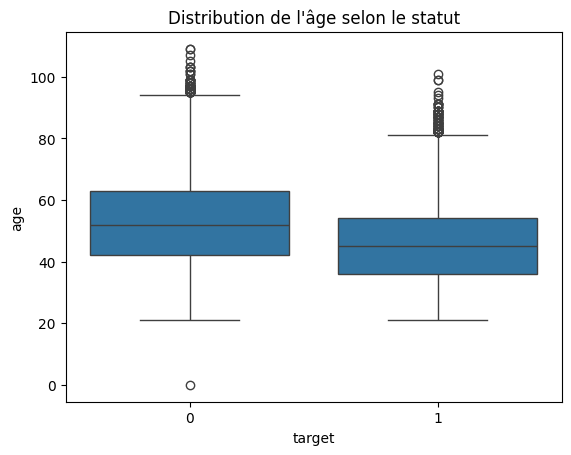

In [23]:
# 1. Vérifier le déséquilibre de la cible
print(f"age moyen pour prendre le credit est de {data_score_credit['age'].mean()}")

# 2. Comparer la moyenne du taux d'utilisation du crédit selon la cible
print(data_score_credit.groupby('target')['taux_utilisation_credit'].mean())


sns.boxplot(x='target', y='age', data=data_score_credit)
plt.title("Distribution de l'âge selon le statut")
plt.show()

# distribution des personnes qui prennent le plus du credit et pourquoi?

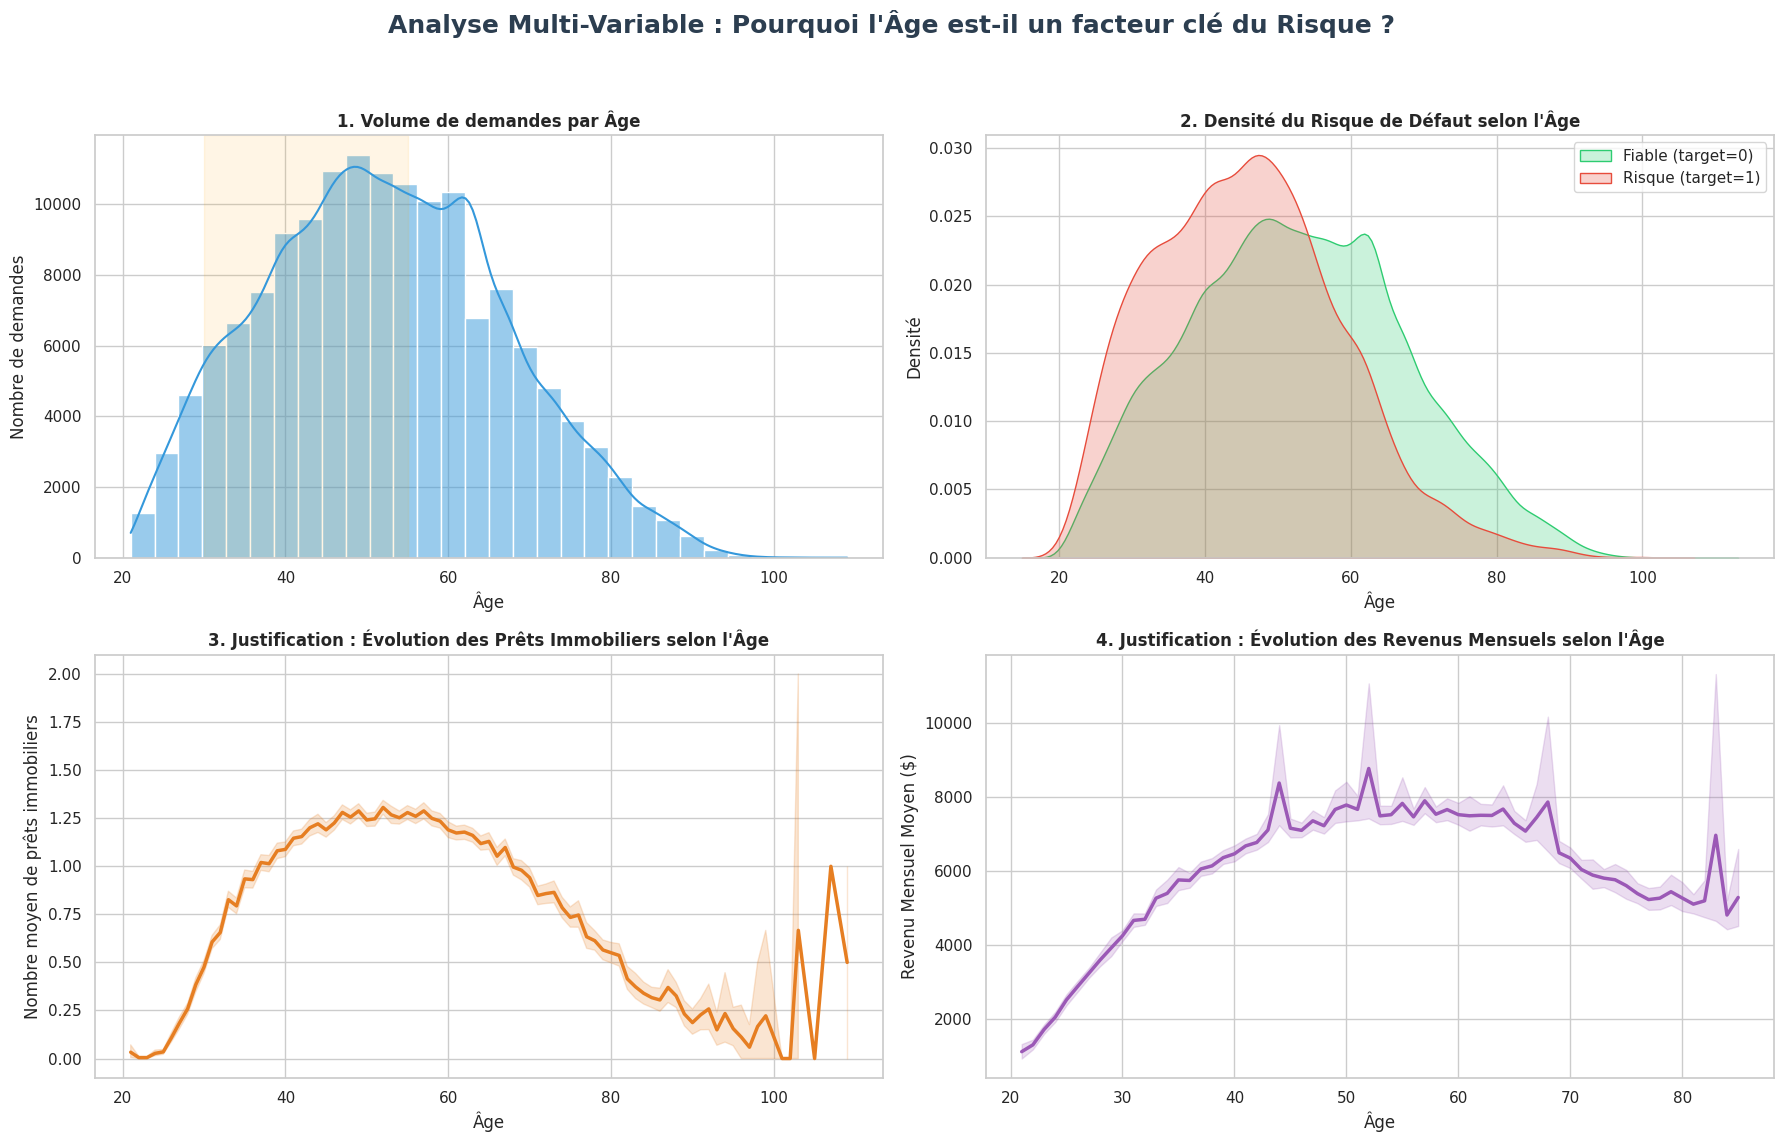

In [27]:
# On ne conserve que les lignes où l'âge est strictement supérieur à 17 ans
data_score_credit = data_score_credit[data_score_credit['age'] >= 18]
# Configurer le style des graphiques
sns.set_theme(style="whitegrid")

# On passe à 2 lignes, 2 colonnes
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Analyse Multi-Variable : Pourquoi l'Âge est-il un facteur clé du Risque ?", 
             fontsize=18, fontweight='bold', color='#2c3e50', y=0.95)

# --- [0, 0] En haut à gauche : Distribution Globale ---
sns.histplot(data=data_score_credit, x='age', kde=True, bins=30, color='#3498db', ax=axes[0, 0])
axes[0, 0].set_title("1. Volume de demandes par Âge", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Âge")
axes[0, 0].set_ylabel("Nombre de demandes")
axes[0, 0].axvspan(30, 55, color='orange', alpha=0.1, label="Tranche active")

# --- [0, 1] En haut à droite : Densité du Risque ---
sns.kdeplot(data=data_score_credit[data_score_credit['target'] == 0], x='age', label='Fiable (target=0)', fill=True, color='#2ecc71', ax=axes[0, 1])
sns.kdeplot(data=data_score_credit[data_score_credit['target'] == 1], x='age', label='Risque (target=1)', fill=True, color='#e74c3c', ax=axes[0, 1])
axes[0, 1].set_title("2. Densité du Risque de Défaut selon l'Âge", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Âge")
axes[0, 1].set_ylabel("Densité")
axes[0, 1].legend()

# --- [1, 0] En bas à gauche : Justification 1 (Prêts Immobiliers) ---
# On regarde le nombre moyen de prêts immobiliers par tranche d'âge
sns.lineplot(data=data_score_credit, x='age', y='nbr_prets_immobilier', color='#e67e22', lw=2.5, ax=axes[1, 0])
axes[1, 0].set_title("3. Justification : Évolution des Prêts Immobiliers selon l'Âge", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Âge")
axes[1, 0].set_ylabel("Nombre moyen de prêts immobiliers")

# --- [1, 1] En bas à droite : Justification 2 (Revenus Mensuels) ---
# On utilise un lineplot (ou un barplot regroupé) pour voir la tendance des revenus sans se faire polluer par les valeurs extrêmes
# Note : On limite l'affichage à l'âge de 18 à 85 ans pour une meilleure visibilité de la courbe
sns.lineplot(data=data_score_credit[data_score_credit['age'] <= 85], x='age', y='Revenus_mensuel', color='#9b59b6', lw=2.5, ax=axes[1, 1])
axes[1, 1].set_title("4. Justification : Évolution des Revenus Mensuels selon l'Âge", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Âge")
axes[1, 1].set_ylabel("Revenu Mensuel Moyen ($)")

# Ajustement parfait des espaces pour éviter les chevauchements
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()